In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np


In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
data.head()

,config_id,index,performance,hp_config.clip_eps,hp_config.ent_coef,hp_config.gae_lambda,hp_config.learning_rate,hp_config.max_grad_norm,hp_config.minibatch_size,hp_config.normalize_advantage,...,hp_config.initial_epsilon,hp_config.learning_starts,hp_config.target_epsilon,hp_config.use_target_network,hp_config.buffer_alpha,hp_config.buffer_beta,hp_config.buffer_epsilon,hp_config.target_update_interval,hp_config.reward_scale,hp_config.tau
0,0,0,4742.1875,0.274407,0.357595,0.920492,0.000530,0.423655,256.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,10,6640.6250,0.191721,0.395863,0.905726,0.000692,0.925597,128.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,20,2000.0000,0.389078,0.435006,0.995626,0.009904,0.461479,512.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,30,1718.7500,0.472334,0.260924,0.882891,0.000021,0.774234,256.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,40,0.0000,0.306048,0.308467,0.988655,0.002565,0.359508,256.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
## performance: per seed performance
## lats_performance: avg over seed performance at the end of training
## last_performance_unnormalized: same as last_performance but without normalization
## max_performance: average over seeds (how?) max performance achieved during training (presumably)

# 1. Normalization

In [5]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False)["_seed_avg"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

data["normed_performance_seedavg"] = data.groupby("env_name", group_keys=False)["_seed_avg"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# 1a). Filter Bad environments

In [6]:
# remove trash environments because they kill the cross-environment ranking later
# bad_envs = ["cc_mountain_car", "minigrid_unlock"]
# data = data[~data["env_name"].isin(bad_envs)]

In [7]:
# zero_seedavg = data[np.abs(data["normed_performance_per_alg_seedavg"]) < 1e-6]
# zero_seedavg = zero_seedavg[["config_id", "env_name", "algorithm", "seed", "performance", "last_performance", "_seed_avg", "last_performance_unnormalized", "max_performance", "normed_performance", "normed_performance_per_alg", "normed_performance_per_alg_seedavg"]]
# zero_seedavg = zero_seedavg[zero_seedavg["algorithm"] == "dqn"]
# zero_seedavg

# 2. Metrics

In [8]:
def get_performance_arrays(
        alg_subset,
        perf_col: str
        ):
    alg_performances = []

    for env in alg_subset["env_name"].unique():

        env_performances = []
        
        for config_id in alg_subset["config_id"].unique():

            env_config_subset = alg_subset[(alg_subset["env_name"]==env) & (alg_subset["config_id"]==config_id)]
            env_performances.append(env_config_subset[perf_col].values)
        
        alg_performances.append(env_performances)
    
    return alg_performances


In [9]:
def tuned_score_per_env(x):
    """
    x: list[list[list[float]]] - shape (envs, configs, seeds)
    
    Computes: avg(max(avg(x, axis=-1), axis=-1), axis=-1) - max(avg(avg(x, axis=-1), axis=0), axis=-1)
    
    First term: For each env, find the best config (by seed-averaged performance), then average across envs
    Second term: Average across envs first, then find the best config
    """
    # avg(x, axis=-1) -> average over seeds: list[list[float]] shape (envs, configs)
    seed_avg = [[np.mean(seeds) for seeds in env] for env in x]
    
    # First term: avg(max(seed_avg, axis=-1), axis=-1)
    # max over configs per env, then average over envs
    max_per_env = [max(env) for env in seed_avg]
    first_term = np.mean(max_per_env)

    # print(max_per_env)
    
    return first_term


def adkins_phi(x):
    """
    x: list[list[list[float]]] - shape (envs, configs, seeds)
    
    Computes: avg(max(avg(x, axis=-1), axis=-1), axis=-1) - max(avg(avg(x, axis=-1), axis=0), axis=-1)
    
    First term: For each env, find the best config (by seed-averaged performance), then average across envs
    Second term: Average across envs first, then find the best config
    """
    # avg(x, axis=-1) -> average over seeds: list[list[float]] shape (envs, configs)
    seed_avg = [[np.mean(seeds) for seeds in env] for env in x]
    
    # First term: avg(max(seed_avg, axis=-1), axis=-1)
    # max over configs per env, then average over envs
    max_per_env = [max(env) for env in seed_avg]
    first_term = np.mean(max_per_env)
    
    # Second term: max(avg(seed_avg, axis=0), axis=-1)
    # average over envs (axis=0), then max over configs
    n_configs = len(seed_avg[0])
    avg_over_envs = [np.mean([seed_avg[env][config] for env in range(len(seed_avg))]) for config in range(n_configs)]
    second_term = max(avg_over_envs)
    
    return first_term - second_term



def transfer_metric(x):
    """
    x: list[list[list[float]]] - shape (envs, configs, seeds)
    
    Computes: avg(max(avg(x, axis=-1), axis=-1), axis=-1) - max(avg(avg(x, axis=-1), axis=0), axis=-1)
    
    First term: For each env, find the best config (by seed-averaged performance), then average across envs
    Second term: Average across envs first, then find the best config
    """
    # avg(x, axis=-1) -> average over seeds: list[list[float]] shape (envs, configs)
    seed_avg = [[np.mean(seeds) for seeds in env] for env in x]
    
    # First term: avg(max(seed_avg, axis=-1), axis=-1)
    # max over configs per env, then average over envs
    max_per_env = [max(env) for env in seed_avg]
    first_term = np.mean(max_per_env)
    
    # Second term: 1/M sum_m seed_avg[m][opt_j(m)]
    # where opt_j(m) = argmax_{m' != m, j} seed_avg[m'][j]
    M = len(seed_avg)
    second_term_values = []
    for m in range(M):
        # Find the best (m', j) pair excluding env m
        best_j = None
        best_val = -np.inf
        for m_prime in range(M):
            if m_prime == m:
                continue
            for j in range(len(seed_avg[m_prime])):
                if seed_avg[m_prime][j] > best_val:
                    best_val = seed_avg[m_prime][j]
                    best_j = j
        
        # Evaluate config best_j on env m
        second_term_values.append(seed_avg[m][best_j])
    
    second_term = np.mean(second_term_values)
    
    return first_term - second_term

In [10]:
def bootstrap_metric(x, metric_fn, n_bootstrap=1000, ci=0.95, seed=None):
    """
    Faster stratified bootstrap using pre-generated indices.
    """
    rng = np.random.default_rng(seed)
    
    # Pre-generate all bootstrap indices for each (env, config)
    boot_indices = [
        [rng.choice(len(config), size=(n_bootstrap, len(config)), replace=True) 
         for config in env]
        for env in x
    ]
    
    # Convert x to numpy arrays for faster indexing
    x_np = [[np.array(config) for config in env] for env in x]
    
    bootstrap_values = []
    for b in range(n_bootstrap):
        x_boot = [
            [x_np[e][c][boot_indices[e][c][b]].tolist() for c in range(len(x[e]))]
            for e in range(len(x))
        ]
        bootstrap_values.append(metric_fn(x_boot))
    
    bootstrap_values = np.array(bootstrap_values)
    
    alpha = 1 - ci
    return {
        "mean": np.mean(bootstrap_values),
        "lower_ci": np.percentile(bootstrap_values, 100 * alpha / 2),
        "upper_ci": np.percentile(bootstrap_values, 100 * (1 - alpha / 2))
    }

In [11]:
def metric_mean_std(x, metric_fn):
    """
    Compute metric, return mean and std in the same format as bootstrap_metric.
    """
    value = metric_fn(x)
    return {
        "mean": value,
        "lower_ci": value - np.std([value]),
        "upper_ci": value + np.std([value])
    }

In [12]:
metric_arrows = {
        "tuned_score_per_env": r"($\uparrow$)",
        "Specifity_gap": r"($\downarrow$)",
        "generalization_gap": r"($\downarrow$)",
    }



def plot_(plot_df,
          title_: str = None, 
          save_axes_prefix=None,
          plot_ylabels=True):
    metric_names = plot_df["metric"].unique()
    algorithms = plot_df["algorithm"].unique()

    palette = sns.color_palette("Set2")
    alg_colors = {alg: palette[i] for i, alg in enumerate(algorithms)}
    # alg_colors = {alg: lindsay_palette[i] for i, alg in enumerate(algorithms)}

    fig, axes = plt.subplots(1, len(metric_names), figsize=(4 * len(metric_names), 4), sharey=True)

    bar_height = 0.6

    for i, (ax, metric) in enumerate(zip(axes, metric_names)):
        metric_df = plot_df[plot_df["metric"] == metric]
        
        for i, alg in enumerate(algorithms):
            alg_data = metric_df[metric_df["algorithm"] == alg]
            if len(alg_data) == 0:
                continue
            
            mean = alg_data["mean"].values[0]
            lower = alg_data["lower_ci"].values[0]
            upper = alg_data["upper_ci"].values[0]
            
            ax.barh(i, upper - lower, left=lower, height=bar_height, 
                    color=alg_colors[alg], alpha=0.8)
            ax.vlines(mean, i - bar_height / 2, i + bar_height / 2, 
                    color='black', linewidth=1.5)
        
        ax.set_yticks(range(len(algorithms)))
        ax.set_yticklabels([alg.upper() for alg in algorithms])
        ax.set_title(metric.replace("_", " ").title() + " " + metric_arrows[metric])
        ax.invert_yaxis()
        
        ax.xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
        ax.set_axisbelow(True)

        max_upper_ci = metric_df["upper_ci"].max()
        min_lower_ci = metric_df["lower_ci"].min()
        ax.set_xlim(min_lower_ci - 0.05, max_upper_ci + 0.05)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        ax.tick_params(axis='y', length=0)
        ax.tick_params(axis='x', length=3)

        # Save each axis as a separate figure by re-plotting
        if save_axes_prefix is not None:
            fig_single, ax_single = plt.subplots(figsize=(4, 4))
            for i, alg in enumerate(algorithms):
                alg_data = metric_df[metric_df["algorithm"] == alg]
                if len(alg_data) == 0:
                    continue
                mean = alg_data["mean"].values[0]
                lower = alg_data["lower_ci"].values[0]
                upper = alg_data["upper_ci"].values[0]
                ax_single.barh(i, upper - lower, left=lower, height=bar_height, 
                               color=alg_colors[alg], alpha=0.8)
                ax_single.vlines(mean, i - bar_height / 2, i + bar_height / 2, 
                                 color='black', linewidth=1.5)
            ax_single.set_yticks(range(len(algorithms)))
            if i == 0 and plot_ylabels:  # Only set y-tick labels for the first subplot
                ax_single.set_yticklabels([alg.upper() for alg in algorithms])
            
            ax_single.set_yticklabels([])
            # ax_single.set_title(metric.replace("_", " ").title() + " " + metric_arrows[metric])
            ax_single.invert_yaxis()
            ax_single.xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
            ax_single.set_axisbelow(True)
            ax_single.set_xlim(min_lower_ci - 0.05, max_upper_ci + 0.05)
            ax_single.spines['top'].set_visible(False)
            ax_single.spines['right'].set_visible(False)
            ax_single.spines['left'].set_visible(False)
            ax_single.tick_params(axis='y', length=0)
            ax_single.tick_params(axis='x', length=3)
            fig_single.tight_layout()
            fig_single.savefig(f"_figures/{save_axes_prefix}_{metric}.pdf")
            plt.close(fig_single)

    if title_:
        fig.suptitle(title_, fontsize=16, y=1.02)
    plt.tight_layout()



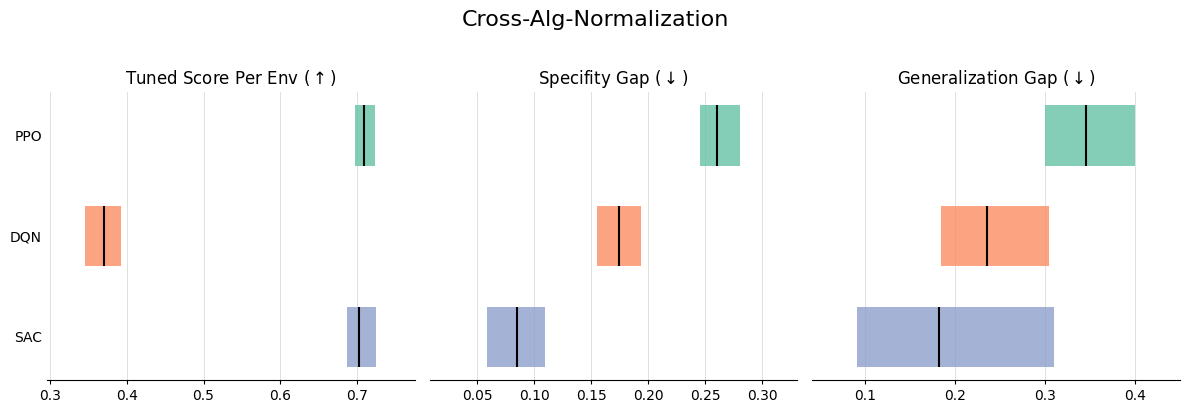

In [13]:
metrics = {}

for alg in algos:
    alg_subset = data[data["algorithm"]==alg]
    alg_performances = get_performance_arrays(alg_subset, perf_col="normed_performance")
    
    tspe_stats = bootstrap_metric(alg_performances, tuned_score_per_env, n_bootstrap=100, seed=42)
    phi_stats = bootstrap_metric(alg_performances, adkins_phi, n_bootstrap=100, seed=42)
    transfer_metric_stats = bootstrap_metric(alg_performances, transfer_metric, n_bootstrap=100, seed=42)

    metrics[alg] = {
        "tuned_score_per_env": tspe_stats,
        "Specifity_gap": phi_stats,
        "generalization_gap": transfer_metric_stats,
    }

plot_data = []
for alg, alg_metrics in metrics.items():
    for metric_name, stats in alg_metrics.items():
        plot_data.append({
            "algorithm": alg,
            "metric": metric_name,
            "mean": stats["mean"],
            "lower_ci": stats["lower_ci"],
            "upper_ci": stats["upper_ci"]
        })

plot_df = pd.DataFrame(plot_data)

plot_(plot_df, title_="Cross-Alg-Normalization", save_axes_prefix="cross_alg_normalization")


# plot_(plot_df, title_="Cross-Alg-Normalization")


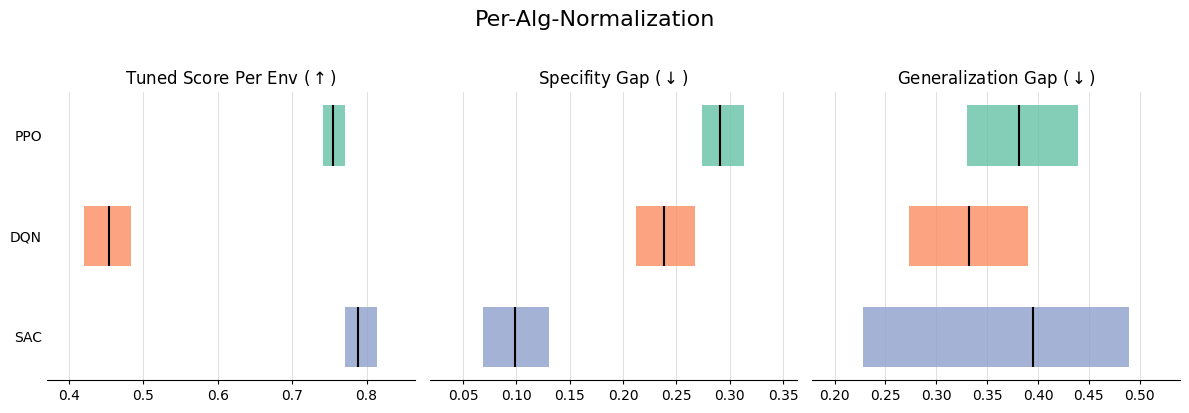

In [14]:
metrics = {}

for alg in algos:
    alg_subset = data[data["algorithm"]==alg]
    alg_performances = get_performance_arrays(alg_subset, perf_col="normed_performance_per_alg")
    
    tspe_stats = bootstrap_metric(alg_performances, tuned_score_per_env, n_bootstrap=100, seed=42)
    phi_stats = bootstrap_metric(alg_performances, adkins_phi, n_bootstrap=100, seed=42)
    transfer_metric_stats = bootstrap_metric(alg_performances, transfer_metric, n_bootstrap=100, seed=42)

    metrics[alg] = {
        "tuned_score_per_env": tspe_stats,
        "Specifity_gap": phi_stats,
        "generalization_gap": transfer_metric_stats,
    }

plot_data = []
for alg, alg_metrics in metrics.items():
    for metric_name, stats in alg_metrics.items():
        plot_data.append({
            "algorithm": alg,
            "metric": metric_name,
            "mean": stats["mean"],
            "lower_ci": stats["lower_ci"],
            "upper_ci": stats["upper_ci"]
        })

plot_df = pd.DataFrame(plot_data)

plot_(plot_df, title_="Per-Alg-Normalization")

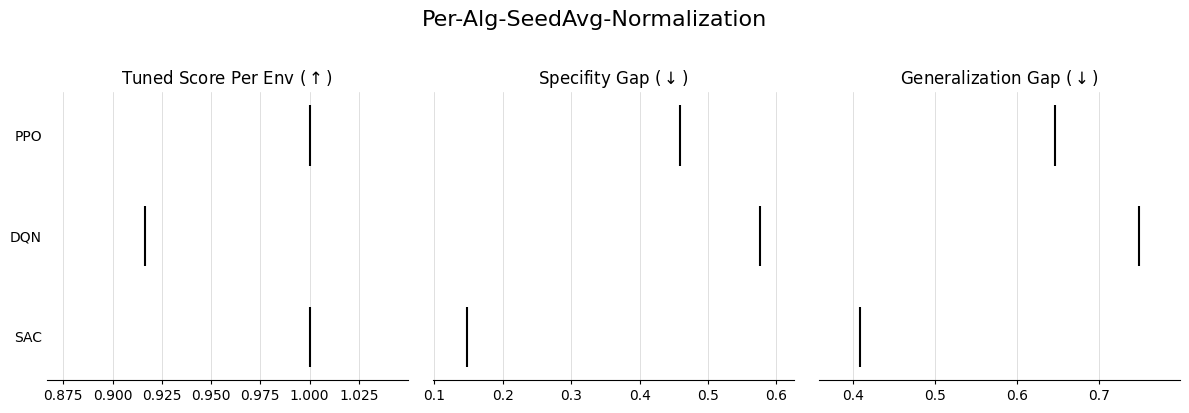

In [15]:
metrics = {}

for alg in algos:
    alg_subset = data[data["algorithm"]==alg]
    alg_performances = get_performance_arrays(alg_subset, perf_col="normed_performance_per_alg_seedavg")

    # print(alg, alg_performances)
    
    # bootstrapping over seeds wouldnt do anything here anyways
    tspe_stats = metric_mean_std(alg_performances, tuned_score_per_env)
    phi_stats = metric_mean_std(alg_performances, adkins_phi)
    transfer_metric_stats = metric_mean_std(alg_performances, transfer_metric)

    metrics[alg] = {
        "tuned_score_per_env": tspe_stats,
        "Specifity_gap": phi_stats,
        "generalization_gap": transfer_metric_stats,
    }

plot_data = []
for alg, alg_metrics in metrics.items():
    for metric_name, stats in alg_metrics.items():
        plot_data.append({
            "algorithm": alg,
            "metric": metric_name,
            "mean": stats["mean"],
            "lower_ci": stats["lower_ci"],
            "upper_ci": stats["upper_ci"]
        })

plot_df = pd.DataFrame(plot_data)

plot_(plot_df, title_="Per-Alg-SeedAvg-Normalization")


The 0.9 from DQN is due to MiniGrid, because it constantly does not achieve anything for any configuration on minigrid_door_key and minigrid_unlock

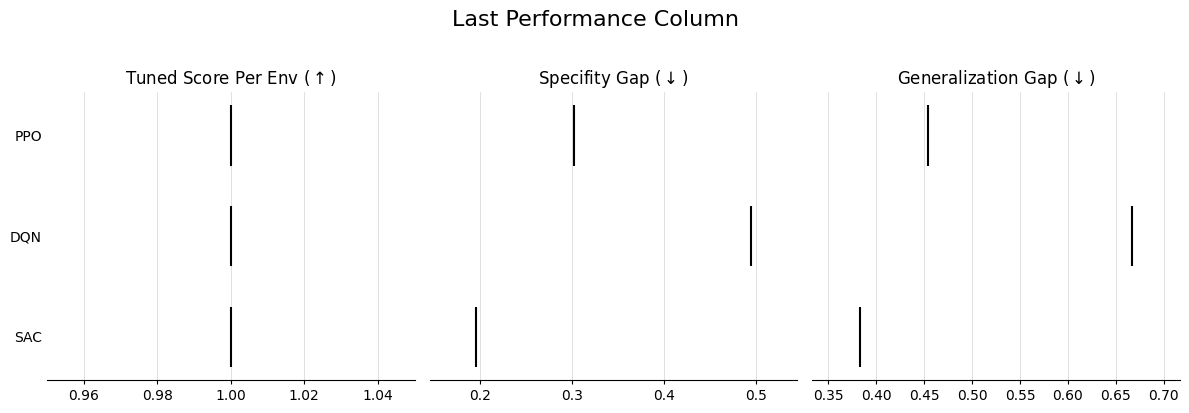

In [16]:
metrics = {}

for alg in algos:
    alg_subset = data[data["algorithm"]==alg]
    alg_performances = get_performance_arrays(alg_subset, perf_col="last_performance")
    
    # bootstrapping over seeds wouldnt do anything here anyways
    tspe_stats = metric_mean_std(alg_performances, tuned_score_per_env)
    phi_stats = metric_mean_std(alg_performances, adkins_phi)
    transfer_metric_stats = metric_mean_std(alg_performances, transfer_metric)

    metrics[alg] = {
        "tuned_score_per_env": tspe_stats,
        "Specifity_gap": phi_stats,
        "generalization_gap": transfer_metric_stats,
    }

plot_data = []
for alg, alg_metrics in metrics.items():
    for metric_name, stats in alg_metrics.items():
        plot_data.append({
            "algorithm": alg,
            "metric": metric_name,
            "mean": stats["mean"],
            "lower_ci": stats["lower_ci"],
            "upper_ci": stats["upper_ci"]
        })

plot_df = pd.DataFrame(plot_data)

plot_(plot_df, title_="Last Performance Column")


# Reconstruct Standard Deviations

In [17]:
def get_plot_data_two(oerf_column):
    other_env_percentiles = []
    other_envs = []
    algorithm_list = []
    env_name_list = []
    domains = []
    other_diffs = []
    best_overall_diffs = []
    for algo in algos:
        algo_subset = data[data["algorithm"] == algo]
        overall_best_config_id = algo_subset.groupby("config_id")[oerf_column].mean().idxmax()
        for env in envs:
            env_subset = algo_subset[algo_subset["env_name"] == env]
            if len(env_subset) == 0:
                continue
            env_best = env_subset[oerf_column].max()
            env_best_config_id = env_subset[env_subset[oerf_column] == env_best]["config_id"].values[0]
            for other_env in envs:
                if other_env == env:
                    continue
                other_env_subset = algo_subset[algo_subset["env_name"] == other_env]
                if len(other_env_subset) == 0:
                    continue
                performance_in_other_env = other_env_subset[other_env_subset["config_id"] == env_best_config_id][oerf_column].values[0]
                overall_best_performance = env_subset[env_subset["config_id"] == overall_best_config_id][oerf_column].values[0]
                percentile_of_config_in_other_env = (other_env_subset[oerf_column] < performance_in_other_env).mean() * 100
                diff_to_other_env = env_best - performance_in_other_env 
                diff_to_overall_best = env_best - overall_best_performance
                other_env_percentiles.append(percentile_of_config_in_other_env)
                other_envs.append(other_env)
                algorithm_list.append(algo)
                env_name_list.append(env)
                domains.append(env.split("_")[0])
                other_diffs.append(diff_to_other_env)
                best_overall_diffs.append(diff_to_overall_best)
    similarity_df = pd.DataFrame({
        "env_name": env_name_list,
        "other_env": other_envs,
        "algorithm": algorithm_list,
        "percentile_in_other_env": other_env_percentiles,
        "diff_to_other_env": other_diffs,
        "domain": domains,
        "diff_to_overall_best": best_overall_diffs
    })

    plot_data = []
    for algo in algos:
        for metric_name in ["diff_to_other_env", "diff_to_overall_best"]:
            plot_data.append({
                "algorithm": algo,
                "metric": metric_name,
                "mean": similarity_df[similarity_df["algorithm"] == algo][metric_name].mean(),
                "lower_ci": similarity_df[similarity_df["algorithm"] == algo][metric_name].mean() - similarity_df[similarity_df["algorithm"] == algo][metric_name].std(),
                "upper_ci": similarity_df[similarity_df["algorithm"] == algo][metric_name].mean() + similarity_df[similarity_df["algorithm"] == algo][metric_name].std()
            })

    return plot_data

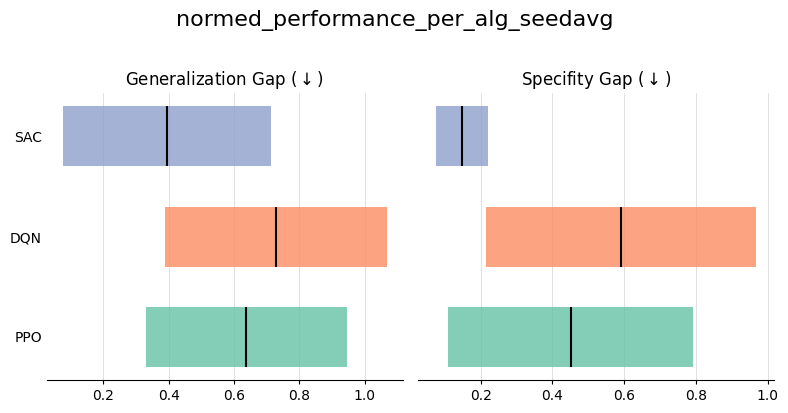

In [18]:
perf_column = "normed_performance_per_alg_seedavg"

plot_data = get_plot_data_two(perf_column)

plot_df = pd.DataFrame(plot_data)

# replace diff_to_other_env by Generalization gap and diff_to_overall_best by Specificity gap in metric column
plot_df["metric"] = plot_df["metric"].replace({
    "diff_to_other_env": "generalization_gap",
    "diff_to_overall_best": "Specifity_gap"
})

plot_(plot_df, title_=perf_column, save_axes_prefix="cross_alg_normalization_seedavg", plot_ylabels=False)

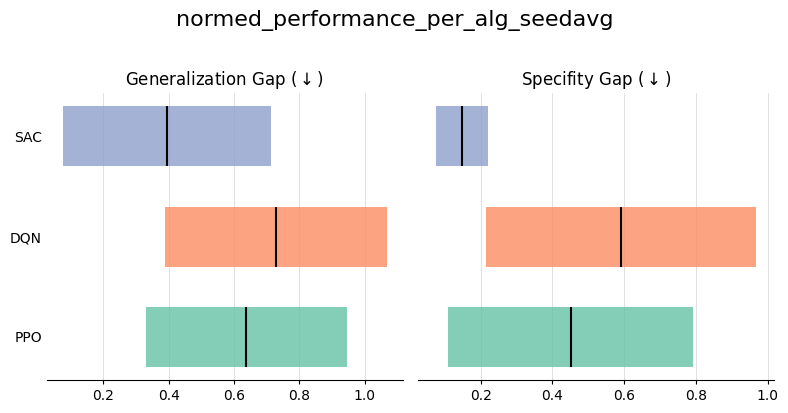

In [19]:
# replace diff_to_other_env by Generalization gap and diff_to_overall_best by Specificity gap in metric column
plot_df["metric"] = plot_df["metric"].replace({
    "diff_to_other_env": "generalization_gap",
    "diff_to_overall_best": "Specifity_gap"
})

plot_(plot_df, title_=perf_column)